# ***VGG 16 Transfer Learning in Keras***

***Dataset Link :- https://universe.roboflow.com/universidadde-de-trsosmontes-e-alto-douro/rotten-apples-detection***

***Dataset Name :- Good & Rotten Apples***

***1.Let's Download the Dataset using Roboflow***

In [1]:
!pip install roboflow

!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="ZjNaKTsBVMjuyqZJmB9S")
project = rf.workspace("universidadde-de-trsosmontes-e-alto-douro").project("rotten-apples-detection")
version = project.version(5)
dataset = version.download("folder")



loading Roboflow workspace...
loading Roboflow project...


***2. Imports***

In [2]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense,Flatten,Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import os

***3.Setup***

In [3]:
base_dir = '/content/Rotten-apples-detection-5' # Replace with your path
train_dir = os.path.join(base_dir,'train')
valid_dir = os.path.join(base_dir,'valid')

***4.Load and preprocess data***

In [4]:
img_size = 224
batch_size = 16

***`ImageDataGenerator helps prepare images for CNN training and can generate augmented versions of training images to reduce overfitting.`***

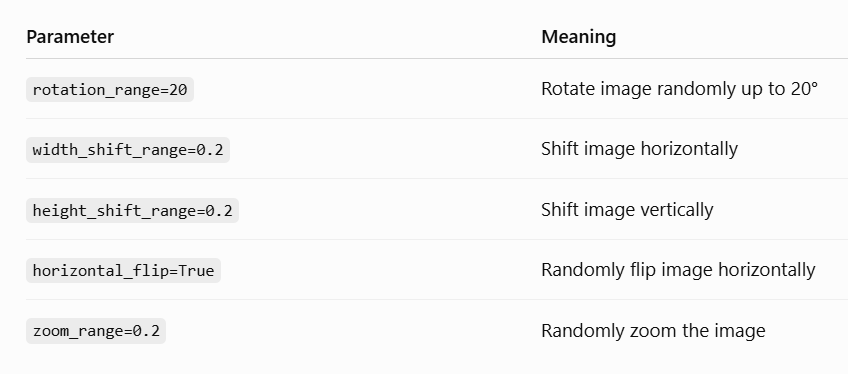

In [5]:
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 20,
    zoom_range = 0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

In [6]:
!cd /content/Rotten-apples-detection-5/train

In [7]:
!pwd

/content


In [8]:
%cd /content/Rotten-apples-detection-5/train

/content/Rotten-apples-detection-5/train


In [9]:
!pwd

/content/Rotten-apples-detection-5/train


In [10]:
!ls

'Good Apple'  'Good Apple Rotten Apple'  'Rotten Apple'


In [11]:
!rm -rf 'Good Apple Rotten Apple'

In [12]:
!ls

'Good Apple'  'Rotten Apple'


***What is a Data Generator?***

***`In deep learning, a data generator is a tool that loads and prepares data in small batches instead of loading the entire dataset into memory at once.`***

In [13]:
train_gen = train_datagen.flow_from_directory(
    train_dir,target_size=(img_size,img_size),batch_size=batch_size,class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    valid_dir,target_size=(img_size,img_size),batch_size=batch_size,class_mode='categorical'
)

Found 777 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


In [14]:
train_gen.num_classes

2

***4. Load VGG16 base model***

In [15]:
base_model = VGG16(weights='imagenet',include_top=False,input_shape=(img_size,img_size,3))
base_model.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


***5. Add custom classification head***

In [17]:
x = base_model.output
x = Flatten()(x)
x = Dense(128,activation='relu')(x)
x = Dropout(0.5)(x)
pred = Dense(train_gen.num_classes,activation='sigmoid')(x)

In [19]:
model = Model(inputs=base_model.input,outputs = pred)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,926,338 (68.38 MB)

 Trainable params: 3,211,650 (12.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

***Model Compile***

In [21]:
#  Compile Model
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])


***Model Training***

In [22]:
hist = model.fit(train_gen,epochs=10,
                 validation_data=val_gen,
                 )

Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 485s 10s/step - accuracy: 0.6602 - loss: 0.9185 - val_accuracy: 0.9600 - val_loss: 0.3531
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 467s 10s/step - accuracy: 0.7851 - loss: 0.4523 - val_accuracy: 0.9800 - val_loss: 0.1924
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 466s 10s/step - accuracy: 0.8314 - loss: 0.3637 - val_accuracy: 0.9700 - val_loss: 0.1457
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 467s 10s/step - accuracy: 0.8507 - loss: 0.3138 - val_accuracy: 0.9800 - val_loss: 0.1001
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 467s 10s/step - accuracy: 0.8752 - loss: 0.2973 - val_accuracy: 0.9900 - val_loss: 0.0996
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 467s 10s/step - accuracy: 0.8610 - loss: 0.2980 - val_accuracy: 0.9900 - val_loss: 0.0745
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 466s 10s/step - accuracy: 0.8764 - loss: 0.3052 - val_accuracy: 0.9800 - val_loss: 0.1119
Epoch 8/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 468s 10s/step - accuracy: 0.8880 - loss: 0.2746 - val_accuracy: 0.

***Model Evaluation***

In [23]:
loss,acc = model.evaluate(val_gen)
print(f"Test Accuracy: {acc:.2f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 52s 7s/step - accuracy: 0.9900 - loss: 0.1037
Test Accuracy: 0.99
